In [1]:
# Install if needed
# !pip install mne pandas numpy matplotlib seaborn tqdm

import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

In [2]:
# Root directory containing EEG files
DATA_DIR = Path("../../data/raw_data/ds006648-download")

# Output folder for evaluation reports
OUTPUT_DIR = Path("../../results/reports")
OUTPUT_DIR.mkdir(exist_ok=True)

# Find all EEGLAB files
eeg_files = list(DATA_DIR.rglob("sub-*/eeg/*.set"))

print("Total EEG files found:", len(eeg_files))

Total EEG files found: 47


In [3]:
def evaluate_eeg(file_path):

    try:
        raw = mne.io.read_raw_eeglab(file_path, preload=False, verbose=False)

        info = raw.info

        subject_data = {}

        # Basic metadata
        subject_data["file"] = file_path.name
        subject_data["n_channels"] = info["nchan"]
        subject_data["sfreq"] = info["sfreq"]
        subject_data["duration_sec"] = raw.n_times / info["sfreq"]
        subject_data["duration_min"] = subject_data["duration_sec"] / 60

        # Channel names
        subject_data["channel_names"] = ",".join(info["ch_names"])

        # Channel types
        subject_data["channel_type_example"] = mne.channel_type(raw.info, 0)

        # Extract events
        events, event_dict = mne.events_from_annotations(raw)

        subject_data["n_events"] = len(events)
        subject_data["unique_event_types"] = len(event_dict)

        # Count each event
        event_counts = {}

        for event in events[:, 2]:
            event_counts[event] = event_counts.get(event, 0) + 1

        subject_data["event_counts"] = str(event_counts)

        # Detect flat channels
        data, times = raw[:10]  # only first few channels small sample
        flat_channels = []

        for i, ch in enumerate(raw.ch_names[:10]):
            if np.std(data[i]) < 1e-10:
                flat_channels.append(ch)

        subject_data["flat_channels_detected"] = ",".join(flat_channels)

        return subject_data

    except Exception as e:
        return {"file": file_path.name, "error": str(e)}

In [4]:
results = []

for file in tqdm(eeg_files):
    res = evaluate_eeg(file)
    results.append(res)

results_df = pd.DataFrame(results)
results_df.head()

  0%|          | 0/47 [00:00<?, ?it/s]/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/1577674993.py:4: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(file_path, preload=False, verbose=False)


Used Annotations descriptions: [np.str_('65281'), np.str_('65282'), np.str_('65283'), np.str_('65284'), np.str_('65285'), np.str_('65286'), np.str_('65287'), np.str_('65288')]


/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/1577674993.py:4: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(file_path, preload=False, verbose=False)
  2%|▏         | 1/47 [00:02<01:45,  2.29s/it]/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/1577674993.py:4: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(file_path, preload=False, verbose=False)


Used Annotations descriptions: [np.str_('65280'), np.str_('65281'), np.str_('65282'), np.str_('65283'), np.str_('65284'), np.str_('65285'), np.str_('65286'), np.str_('65287'), np.str_('65288')]


/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/1577674993.py:4: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(file_path, preload=False, verbose=False)
  4%|▍         | 2/47 [00:05<02:02,  2.73s/it]/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/1577674993.py:4: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(file_path, preload=False, verbose=False)


...

Used Annotations descriptions: [np.str_('65280'), np.str_('65281'), np.str_('65282'), np.str_('65283'), np.str_('65284'), np.str_('65285'), np.str_('65286'), np.str_('65287'), np.str_('65288')]


/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/1577674993.py:4: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(file_path, preload=False, verbose=False)
 98%|█████████▊| 46/47 [05:23<00:06,  6.54s/it]/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/1577674993.py:4: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(file_path, preload=False, verbose=False)


Used Annotations descriptions: [np.str_('65281'), np.str_('65282'), np.str_('65283'), np.str_('65284'), np.str_('65285'), np.str_('65286'), np.str_('65287'), np.str_('65288')]


/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/1577674993.py:4: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(file_path, preload=False, verbose=False)
100%|██████████| 47/47 [05:39<00:00,  7.22s/it]


,file,n_channels,sfreq,duration_sec,duration_min,channel_names,channel_type_example,n_events,unique_event_types,event_counts,flat_channels_detected
0,sub-021_task-readpoetry_eeg.set,70,512.0,7514.0,125.233333,"Fp1,AF7,AF3,F1,F3,F5,F7,FT7,FC5,FC3,FC1,C1,C3,...",eeg,853,8,"{np.int64(4): 213, np.int64(5): 1, np.int64(6)...",
1,sub-026_task-readpoetry_eeg.set,70,512.0,7283.0,121.383333,"Fp1,AF7,AF3,F1,F3,F5,F7,FT7,FC5,FC3,FC1,C1,C3,...",eeg,853,9,"{np.int64(1): 1, np.int64(6): 1, np.int64(7): ...",
2,sub-019_task-readpoetry_eeg.set,70,512.0,6736.0,112.266667,"Fp1,AF7,AF3,F1,F3,F5,F7,FT7,FC5,FC3,FC1,C1,C3,...",eeg,853,8,"{np.int64(4): 213, np.int64(5): 1, np.int64(6)...",
3,sub-010_task-readpoetry_eeg.set,70,512.0,7566.0,126.100000,"Fp1,AF7,AF3,F1,F3,F5,F7,FT7,FC5,FC3,FC1,C1,C3,...",eeg,853,8,"{np.int64(4): 213, np.int64(5): 1, np.int64(6)...",
4,sub-017_task-readpoetry_eeg.set,70,512.0,6746.0,112.433333,"Fp1,AF7,AF3,F1,F3,F5,F7,FT7,FC5,FC3,FC1,C1,C3,...",eeg,853,9,"{np.int64(1): 1, np.int64(6): 1, np.int64(7): ...",


In [5]:
report_file = OUTPUT_DIR / "raw_eeg_quality_report.csv"

results_df.to_csv(report_file, index=False)

print("Report saved to:", report_file)

Report saved to: ../../results/reports/raw_eeg_quality_report.csv


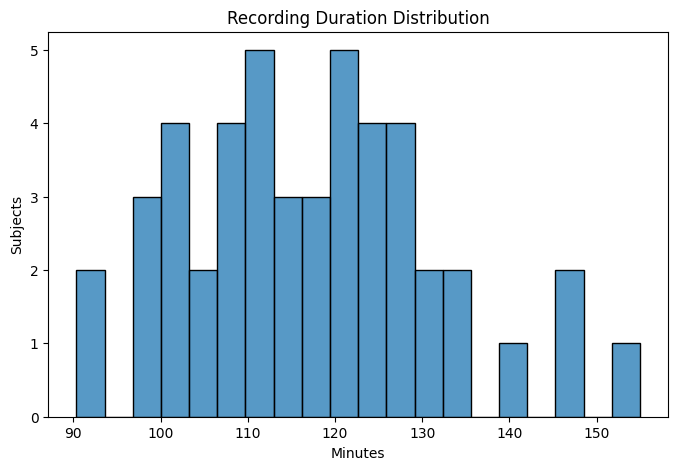

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(results_df["duration_min"], bins=20)

plt.title("Recording Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Subjects")
plt.show()

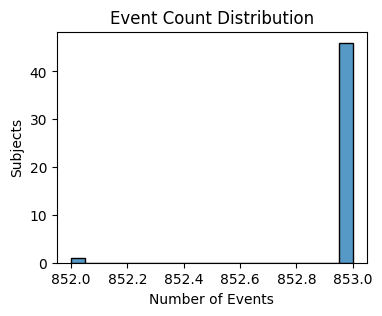

In [9]:
plt.figure(figsize=(4, 3))
sns.histplot(results_df["n_events"], bins=20)

plt.title("Event Count Distribution")
plt.xlabel("Number of Events")
plt.ylabel("Subjects")
plt.show()

/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/1883199985.py:3: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(sample_file, preload=False)
/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/1883199985.py:3: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(sample_file, preload=False)


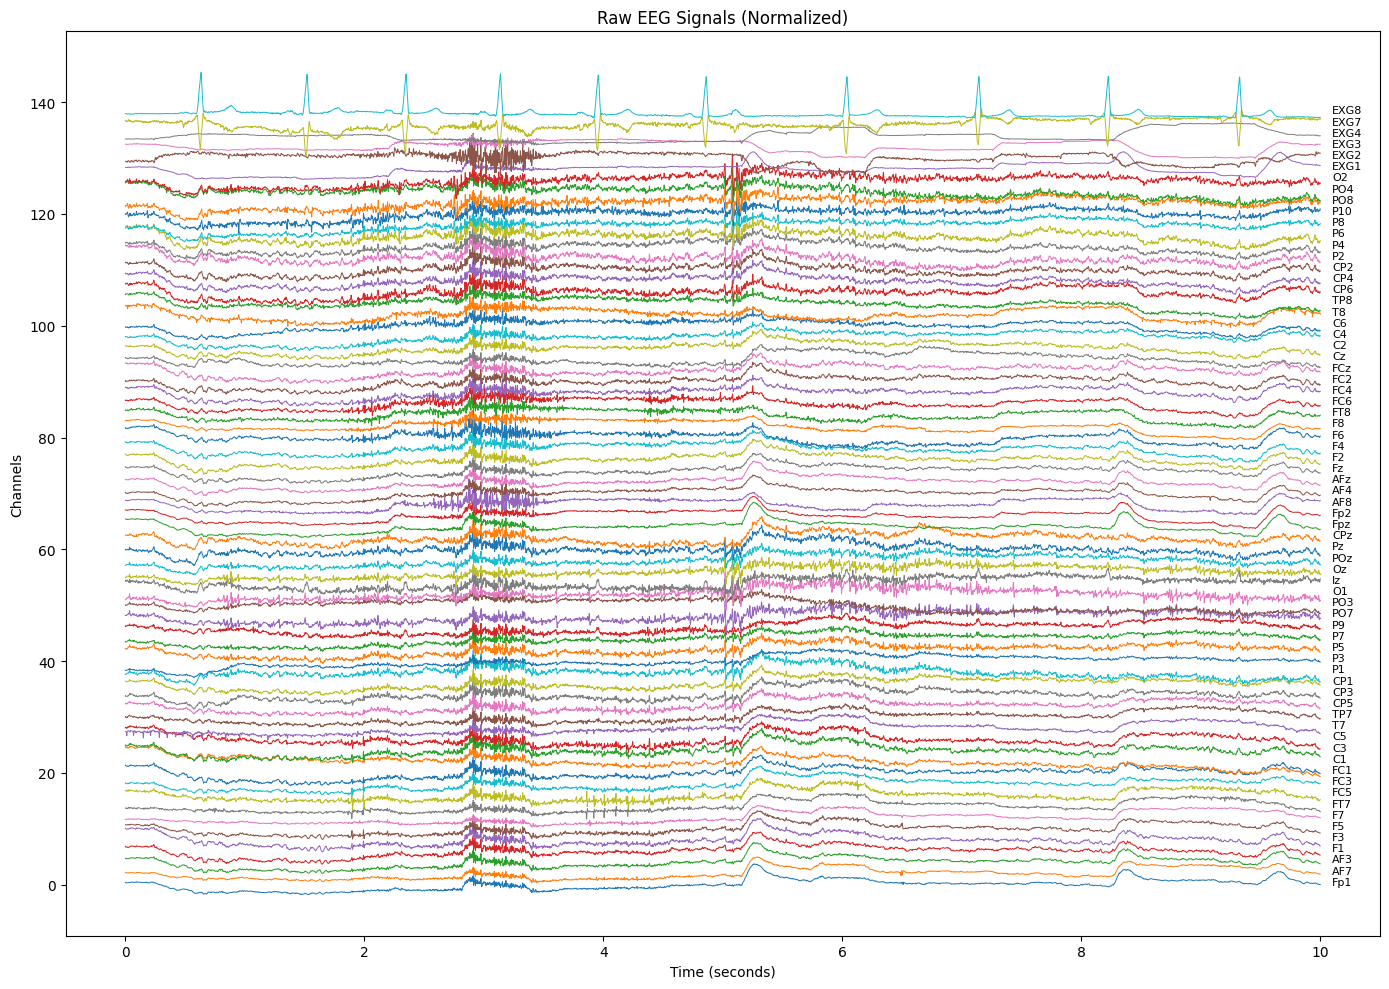

In [16]:
sample_file = eeg_files[1]

raw = mne.io.read_raw_eeglab(sample_file, preload=False)

# raw.plot(n_channels=20, duration=10)
sfreq = raw.info["sfreq"]

start_time = 0  # seconds
duration = 10  # seconds

start_sample = int(start_time * sfreq)
end_sample = int((start_time + duration) * sfreq)
data, times = raw[:, start_sample:end_sample]
times = times - times[0]
plt.figure(figsize=(14, 10))

offset = 0
spacing = 2

for i in range(data.shape[0]):

    signal = data[i]
    signal = (signal - np.mean(signal)) / np.std(signal)

    plt.plot(times, signal + offset, linewidth=0.7)
    plt.text(times[-1] + 0.1, offset, raw.ch_names[i], fontsize=8)

    offset += spacing


plt.xlabel("Time (seconds)")
plt.ylabel("Channels")
plt.title("Raw EEG Signals (Normalized)")
plt.tight_layout()
plt.show()

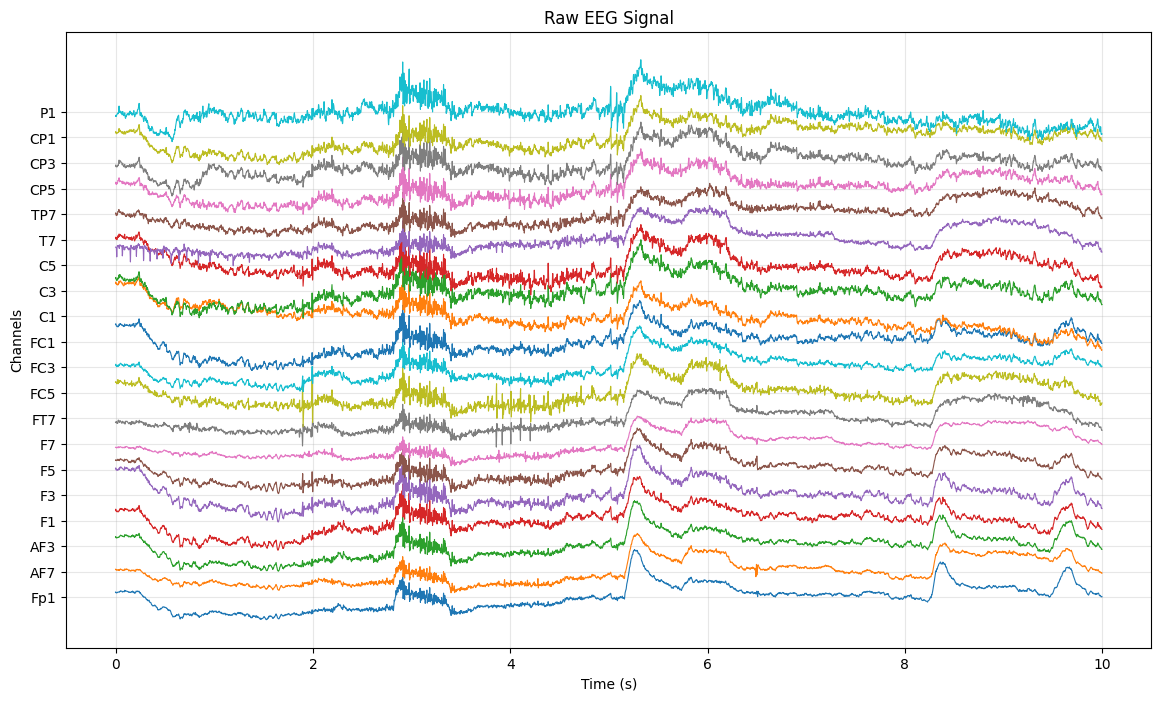

In [20]:
def plot_raw_matplotlib(raw, channels=20, duration=10, normalize=True):

    sfreq = raw.info["sfreq"]

    # extract data
    data, times = raw[:channels, : int(duration * sfreq)]

    # convert to microvolts
    data = data * 1e6

    if normalize:
        data = (data - np.mean(data, axis=1, keepdims=True)) / np.std(
            data, axis=1, keepdims=True
        )

    # offset signals for visualization
    offset = np.arange(channels) * 2
    data = data + offset[:, None]

    plt.figure(figsize=(14, 8))

    for i in range(channels):
        plt.plot(times, data[i], linewidth=0.8)

    plt.yticks(offset, raw.ch_names[:channels])
    plt.xlabel("Time (s)")
    plt.ylabel("Channels")
    plt.title("Raw EEG Signal")
    plt.grid(alpha=0.3)

    plt.show()


plot_raw_matplotlib(raw, channels=20, duration=10)

/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/4057372094.py:3: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(sample_file, preload=False)
/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/4057372094.py:3: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(sample_file, preload=False)


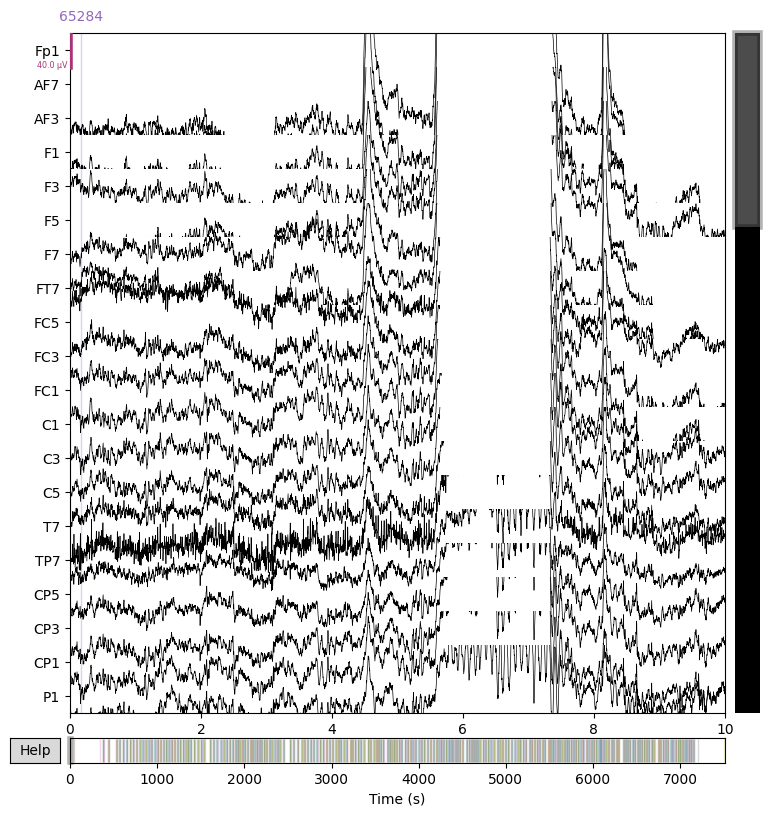

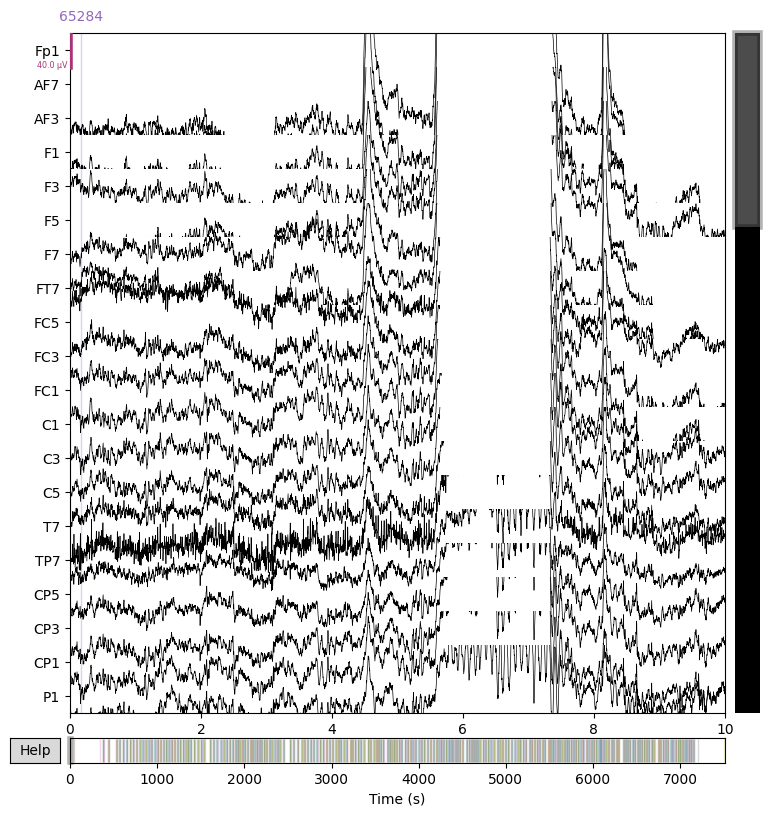

In [21]:
sample_file = eeg_files[0]

raw = mne.io.read_raw_eeglab(sample_file, preload=False)

raw.plot(n_channels=20, duration=10)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().


/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/546151696.py:1: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(sample_file, preload=True)


Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


/var/folders/hr/_514t0p560s6wx_xmwzg_vnm0000gn/T/ipykernel_21630/546151696.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd(fmax=60)
/Users/pramit/Documents/projects/neuro_astic/.ptanlys_venv/lib/python3.9/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


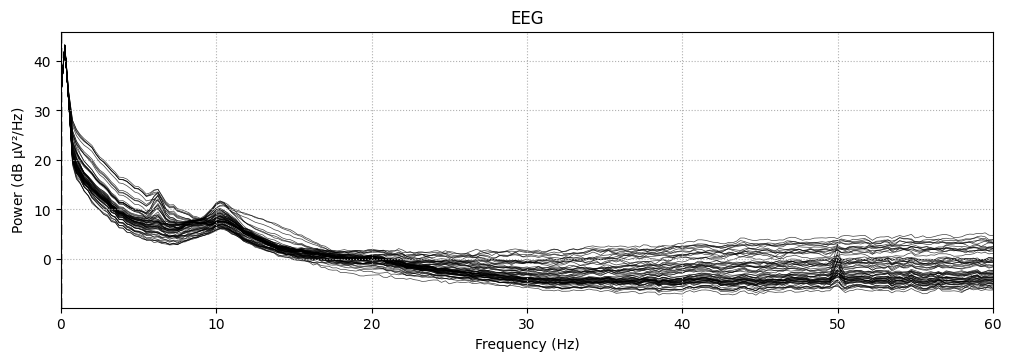

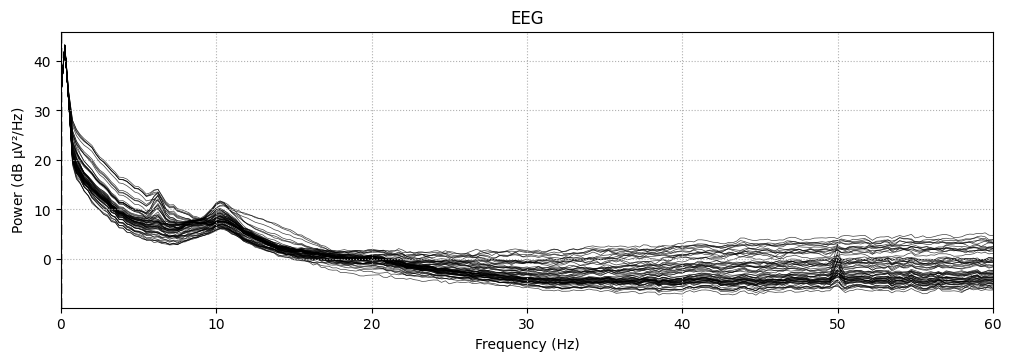

In [22]:
raw = mne.io.read_raw_eeglab(sample_file, preload=True)

raw.plot_psd(fmax=60)

Used Annotations descriptions: [np.str_('65281'), np.str_('65282'), np.str_('65283'), np.str_('65284'), np.str_('65285'), np.str_('65286'), np.str_('65287'), np.str_('65288')]


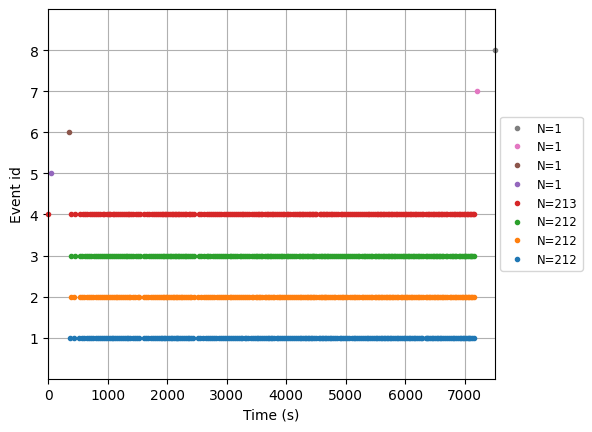

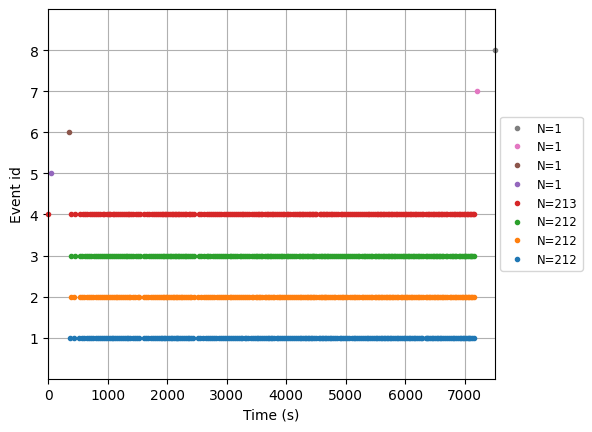

In [24]:
events, event_id = mne.events_from_annotations(raw)

mne.viz.plot_events(events, sfreq=raw.info["sfreq"])